In [4]:
from nwm_routing.nhf_routing import nhf_routing
import os
from pathlib import Path
import logging
import xarray as xr
import matplotlib.pyplot as plt

logging.getLogger("matplotlib").setLevel(logging.WARNING)

if Path().cwd().name != "data":  # Guard against reruns
    os.chdir("data/")

In [9]:
REF_DATA = Path("config/gage_reference_data.nc")
OUT_DIR  = Path("comparison_plots")
OUT_DIR.mkdir(exist_ok=True)

C_USGS = "#1a1a1a"
C_A    = "#2166ac"
C_B    = "#d6604d"

SITES = ["07381482", "07381490", "07374000", "07289000"]


def load_output(output_dir: Path) -> xr.Dataset:
    files = sorted(Path(output_dir).glob("*.nc"))
    if not files:
        raise FileNotFoundError(
            f"No .nc files found in '{output_dir}'. "
            "Run the routing configuration before plotting."
        )
    return xr.concat([xr.open_dataset(p, engine="netcdf4") for p in files], dim="time")


def get_troute_flow(out_ds, fp_id, last_t):
    trdf = out_ds.sel(feature_id=fp_id).to_dataframe().reset_index()
    return trdf[trdf["time"] <= last_t]


def compare_runs(
    output_a: str | Path,
    output_b: str | Path,
    sites: list[str],
    label_a: str = "Run A",
    label_b: str = "Run B",
    suffix: str = "",
    ref_data: Path = REF_DATA,
    out_dir: Path = OUT_DIR,
):
    """Plot observed vs two T-Route runs for each requested gage.

    Parameters
    ----------
    output_a, output_b : directories containing chunked .nc output files
    sites              : list of USGS site numbers to plot
    label_a, label_b   : legend labels for each run
    suffix             : string appended to the output filename (e.g. "_diversion")
    """
    ds    = xr.open_dataset(ref_data)
    ds_a  = load_output(output_a)
    ds_b  = load_output(output_b)

    site_indices = [
        int(i)
        for i, sn in enumerate(ds["site_no"].values)
        if sn in sites
    ]
    assert len(site_indices) == len(sites), (
        f"Not all requested sites found. Available: {list(ds['site_no'].values)}"
    )

    for gage_idx in site_indices:
        sub     = ds.sel(gage=gage_idx)
        site_no = sub["site_no"].item()
        fp_id   = sub["fp_id"].item()
        last_t  = sub["time"].values[-1]

        trdf_a = get_troute_flow(ds_a, fp_id, last_t)
        trdf_b = get_troute_flow(ds_b, fp_id, last_t)

        fig, ax = plt.subplots(figsize=(9, 5))
        ax.plot(
            trdf_a["time"], trdf_a["flow"],
            label=label_a, color=C_A, linewidth=1.5,
            marker="o", markevery=30, markersize=4, markerfacecolor="w", zorder=2,
        )
        ax.plot(
            trdf_b["time"], trdf_b["flow"],
            label=label_b, color=C_B, linewidth=1.5,
            marker="s", markevery=30, markersize=4, markerfacecolor="w", zorder=3,
        )
        ax.plot(
            sub["time"].values, sub["usgs_q"].values / 35.31,
            label=f"USGS {site_no}", color=C_USGS, linewidth=2, zorder=4,
        )
        ax.set_xlabel("Date")
        ax.set_ylabel("Discharge (cms)")
        ax.legend(framealpha=0.9, fontsize=10)
        ax.set_title(f"USGS Site {site_no}  —  fp_id: {fp_id}", fontsize=12)
        ax.set_facecolor("whitesmoke")
        ax.grid(color="white", linewidth=0.8)
        fig.autofmt_xdate()
        fig.tight_layout()
        fig.savefig(out_dir / f"{site_no}{suffix}.png", dpi=150)
        plt.show()


def compare_retro(
    sites: list[str],
    ref_data: Path = REF_DATA,
    out_dir: Path = OUT_DIR,
):
    """Plot NWM retrospective vs. USGS observed for each requested gage.

    Uses solid/dashed black lines with no color to show the pre-DA baseline.

    Parameters
    ----------
    sites    : list of USGS site numbers to plot
    ref_data : path to gage_reference_data.nc
    out_dir  : directory to save figures
    """
    ds = xr.open_dataset(ref_data)

    site_indices = [
        int(i)
        for i, sn in enumerate(ds["site_no"].values)
        if sn in sites
    ]
    assert len(site_indices) == len(sites), (
        f"Not all requested sites found. Available: {list(ds['site_no'].values)}"
    )

    for gage_idx in site_indices:
        sub     = ds.sel(gage=gage_idx)
        site_no = sub["site_no"].item()
        fp_id   = sub["fp_id"].item()

        fig, ax = plt.subplots(figsize=(9, 5))
        ax.plot(
            sub["time"].values, sub["retrospective_q"].values,
            label="NWM v3.0 Retrospective", color=C_USGS, linewidth=1.5,
            linestyle="--", zorder=2,
        )
        ax.plot(
            sub["time"].values, sub["usgs_q"].values / 35.31,
            label=f"USGS {site_no}", color=C_USGS, linewidth=2,
            linestyle="-", zorder=3,
        )
        ax.set_xlabel("Date")
        ax.set_ylabel("Discharge (cms)")
        ax.legend(framealpha=0.9, fontsize=10)
        ax.set_title(f"USGS Site {site_no}  —  fp_id: {fp_id}", fontsize=12)
        ax.set_facecolor("whitesmoke")
        ax.grid(color="white", linewidth=0.8)
        fig.autofmt_xdate()
        fig.tight_layout()
        fig.savefig(out_dir / f"{site_no}_retro.png", dpi=150)
        plt.show()


In [25]:
nhf_routing(["-f", "config.yaml"])
nhf_routing(["-f", "config_no_diversion.yaml"])

2026-07-14 19:45:25,471 - TROUTE - INFO - [NHF.py:79 - __init__]: creating NHF supernetwork connections set


/t-route/src/troute-network/troute/nhf_preprocess.py:424: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  waterbody_df[lake_id_field] = lake_ids.astype(int)
2026-07-14 19:45:25,654 - TROUTE - INFO - [nhf_preprocess.py:505 - _clean_waterbodies]: waterbodies: 2 of 2 lakes retained for reservoir routing
2026-07-14 19:45:25,691 - TROUTE - DEBUG - [nhf_preprocess.py:1101 - _resolve_diversion_da]: Diversion configured: fp_id 1270479816524705 (node 1271023511891281) -> gage 07381482 (node 1270478549293493)
2026-07-14 19:45:25,692 - TROUTE - INFO - [NHF.py:139 - __init__]: supernetwork connections set complete
2026-07-14 19:45:25,692 - TROUTE - INFO - [NHF.py:141 - __init__]: ... in 0.21953344345092773 seconds.
2026-07-14 19:45:25,694 - TROUTE - INFO - [Ab

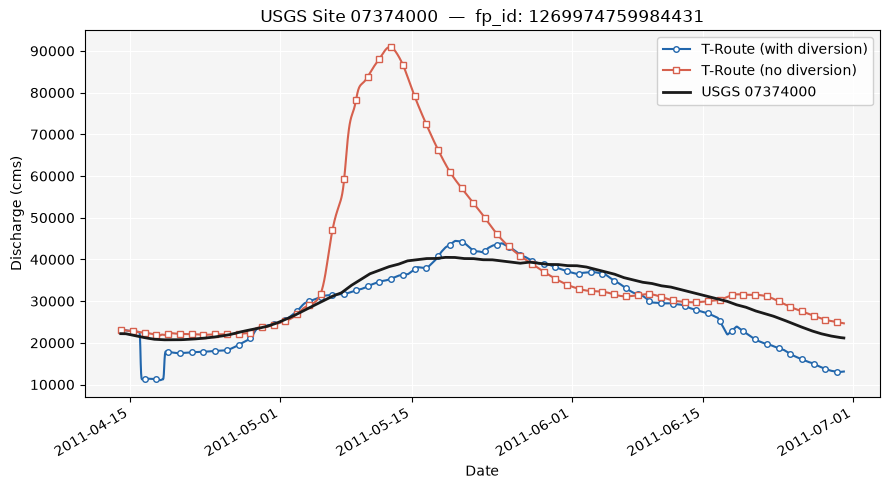

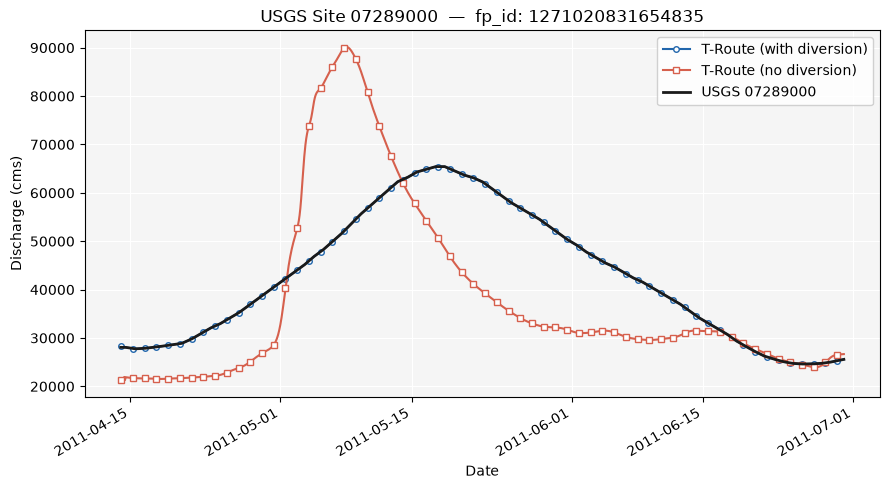

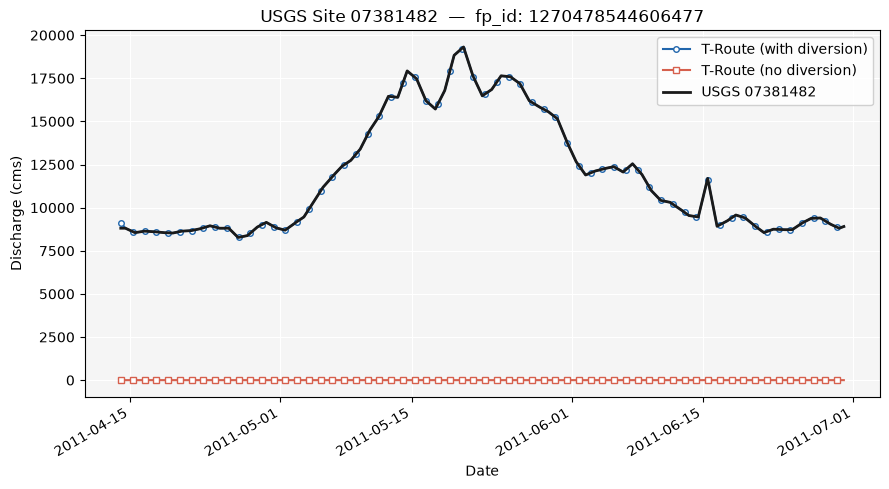

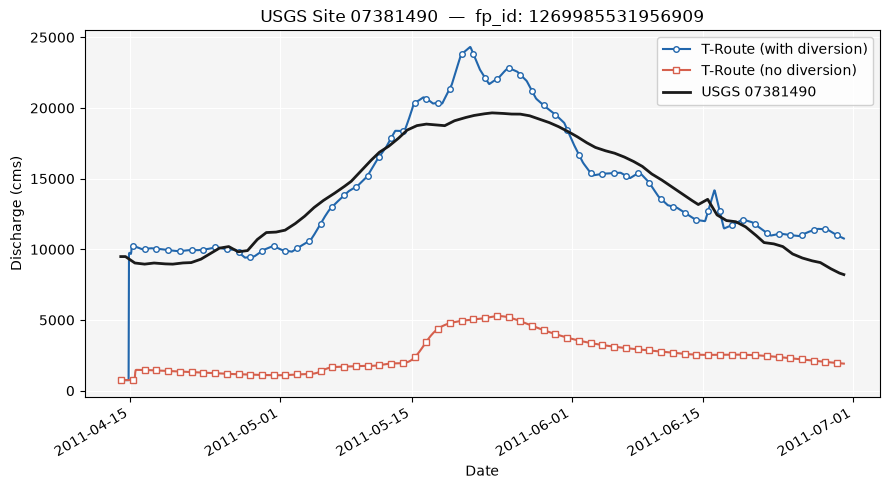

In [10]:

compare_runs(
    output_a="output",
    output_b="output_no_diversion",
    sites=SITES,
    label_a="T-Route (with diversion)",
    label_b="T-Route (no diversion)",
    suffix="_diversion",
)


In [28]:
nhf_routing(["-f", "config_historical.yaml"])

2026-07-14 19:51:06,129 - TROUTE - INFO - [NHF.py:79 - __init__]: creating NHF supernetwork connections set
/t-route/src/troute-network/troute/nhf_preprocess.py:424: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  waterbody_df[lake_id_field] = lake_ids.astype(int)
2026-07-14 19:51:06,204 - TROUTE - INFO - [nhf_preprocess.py:505 - _clean_waterbodies]: waterbodies: 2 of 2 lakes retained for reservoir routing
2026-07-14 19:51:06,225 - TROUTE - DEBUG - [nhf_preprocess.py:1101 - _resolve_diversion_da]: Diversion configured: fp_id 1270479816524705 (node 1271023511891281) -> gage 07381482 (node 1270478549293493)
2026-07-14 19:51:06,225 - TROUTE - INFO - [NHF.py:139 - __init__]: supernetwork connections set complete
2026-07-14 19:51:06,226 - TROUTE - INFO 

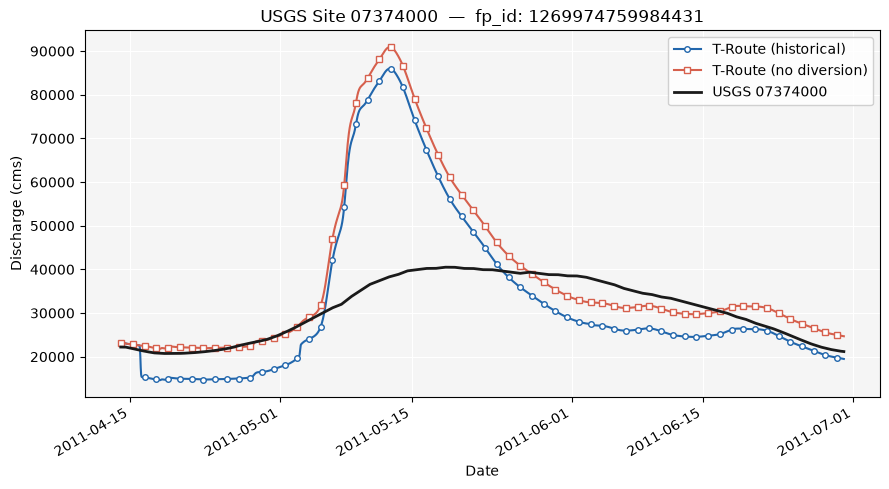

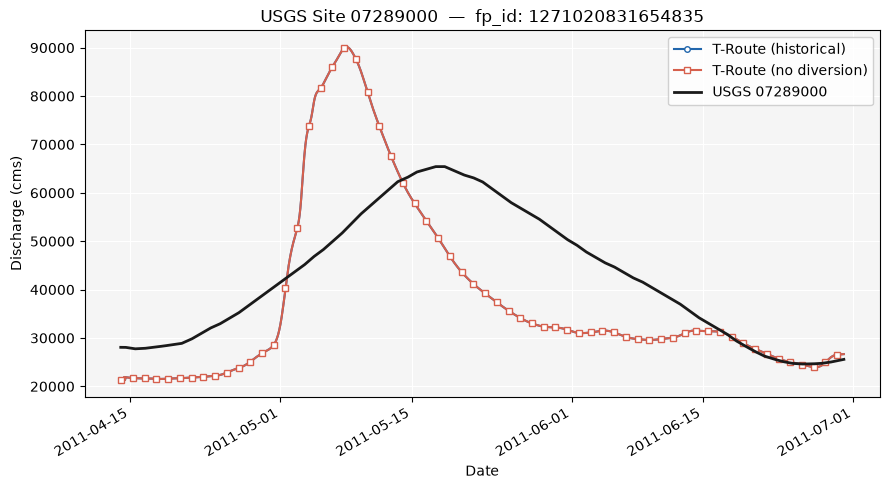

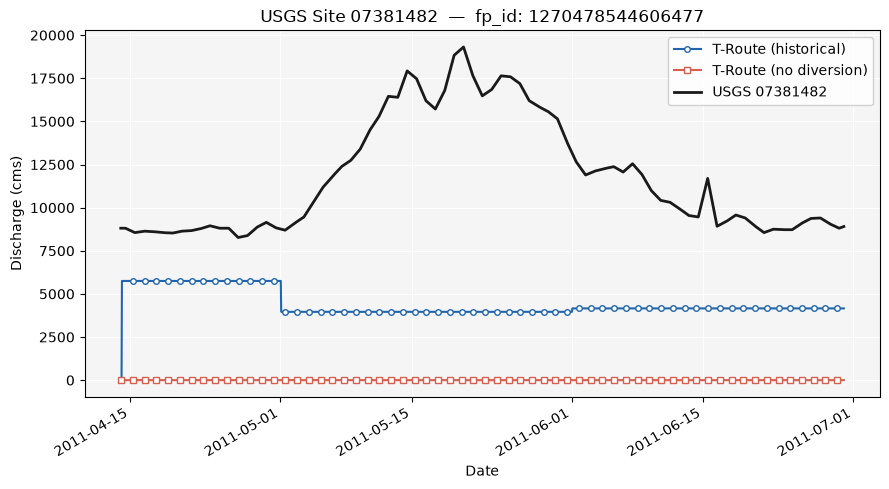

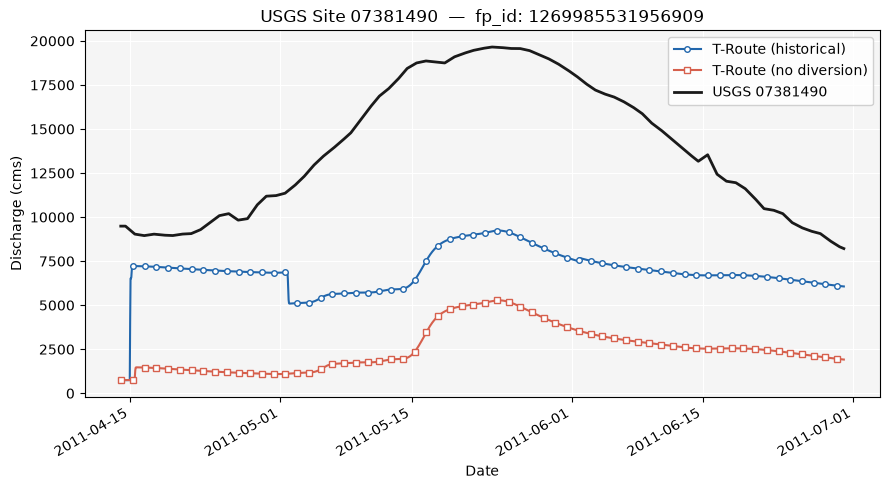

In [11]:
compare_runs(
    output_a="output_historical",
    output_b="output_no_diversion",
    sites=SITES,
    label_a="T-Route (historical)",
    label_b="T-Route (no diversion)",
    suffix="_historical",
)


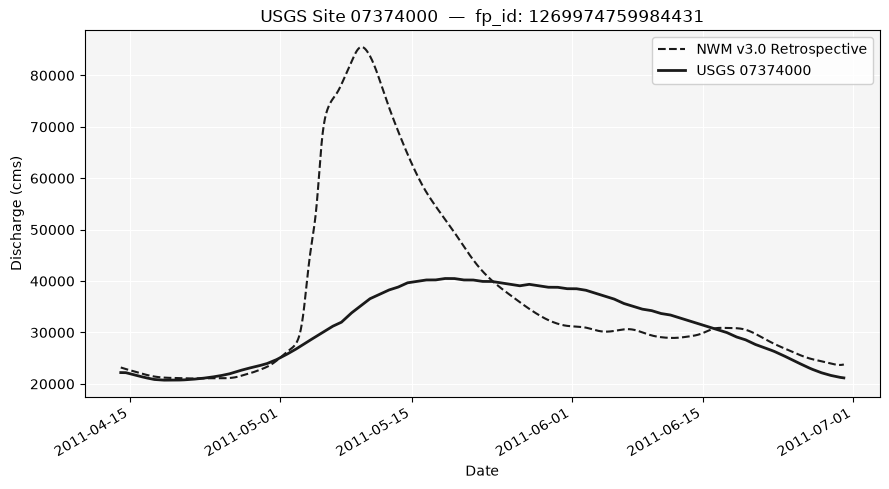

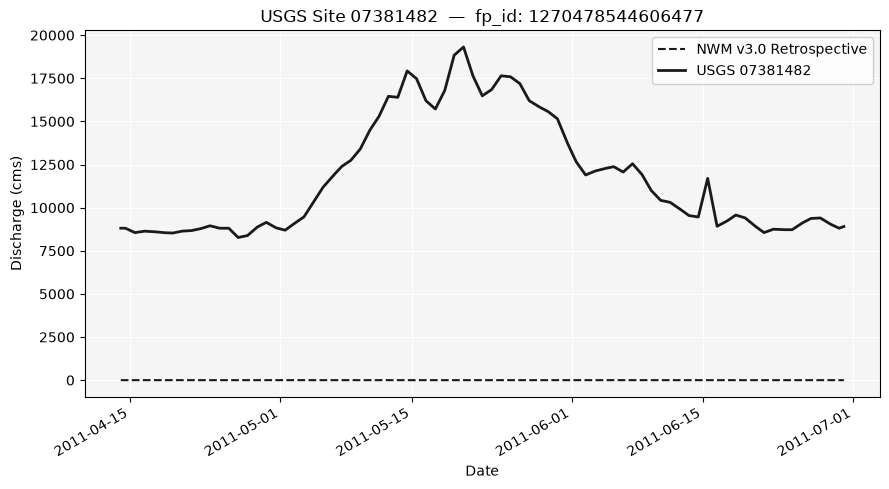

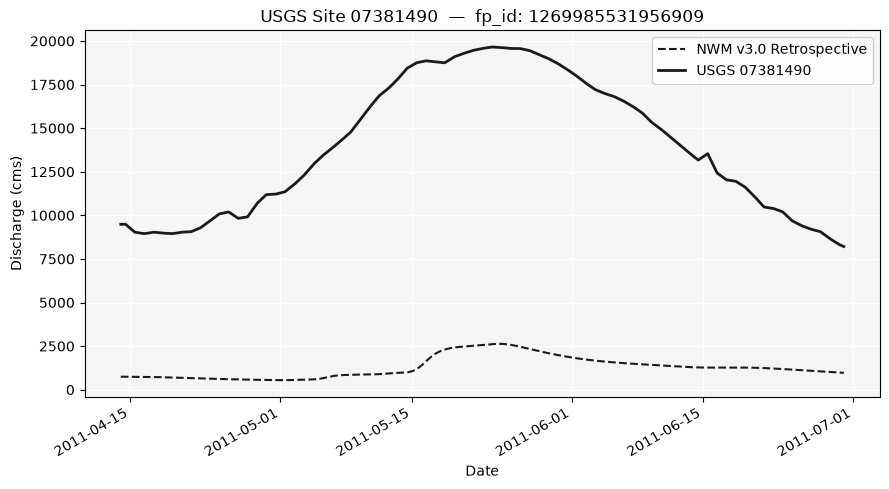

In [8]:
compare_retro(sites=SITES)
